In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('onlinetable.csv')

In [3]:
df.columns = ['rank', 'ewc', 'enc', 'country', 'player', 'china', 'france',
       'usa', 'brazil', 'greece', '? #6', '? #7', '? #8', '? #9',
       '? #10', 'total_points']

df = df[['rank', 'ewc', 'enc', 'country', 'player', 'china', 'france',
       'usa','total_points']]

In [4]:
for col in ['china', 'france','usa']:
    df[f'{col}_spot'] = df[col].apply(lambda x: int(x.split('#')[1].split(')')[0]) if type(x) is str else 65)
    df[f'{col}_points'] = df[col].apply(lambda x: int(x.split('#')[0].split('(')[0]) if type(x) is str else 0)
df

,rank,ewc,enc,country,player,china,france,usa,total_points,china_spot,china_points,france_spot,france_points,usa_spot,usa_points
0,1,NaN,(#1),Australia,AR_Mudda,1000(#1),1000(#1),24(#41),2024,1,1000,1,1000,41,24
1,2,NaN,(#2),France,WosileTM,64(#17),20(#45),1000(#1),1084,17,64,45,20,1,1000
2,3,NaN,(#3),Germany,GranaDy.,600(#3),64(#18),200(#7),864,3,600,18,64,7,200
3,4,NaN,NaN,France,Binkss.,700(#2),100(#8),10(#55),810,2,700,8,100,55,10
4,5,NaN,NaN,France,Nayko.TM,92(#10),700(#2),18(#48),810,10,92,2,700,48,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,NaN,NaN,Norway,Intax,NaN,4(#61),NaN,4,65,0,61,4,65,0
88,89,NaN,NaN,United States,Kakne..,NaN,4(#62),NaN,4,65,0,62,4,65,0
89,90,NaN,NaN,France,V1NCH.,2(#63),NaN,NaN,2,63,2,65,0,65,0
90,91,NaN,NaN,Poland,Demotivator13,NaN,2(#63),NaN,2,65,0,63,2,65,0


In [5]:
df['mean_spot'] = df[['china_spot', 'france_spot', 'usa_spot']].mean(axis=1)
df['rank_by_points'] = df.index+1
df

,rank,ewc,enc,country,player,china,france,usa,total_points,china_spot,china_points,france_spot,france_points,usa_spot,usa_points,mean_spot,rank_by_points
0,1,NaN,(#1),Australia,AR_Mudda,1000(#1),1000(#1),24(#41),2024,1,1000,1,1000,41,24,14.333333,1
1,2,NaN,(#2),France,WosileTM,64(#17),20(#45),1000(#1),1084,17,64,45,20,1,1000,21.000000,2
2,3,NaN,(#3),Germany,GranaDy.,600(#3),64(#18),200(#7),864,3,600,18,64,7,200,9.333333,3
3,4,NaN,NaN,France,Binkss.,700(#2),100(#8),10(#55),810,2,700,8,100,55,10,21.666667,4
4,5,NaN,NaN,France,Nayko.TM,92(#10),700(#2),18(#48),810,10,92,2,700,48,18,20.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,NaN,NaN,Norway,Intax,NaN,4(#61),NaN,4,65,0,61,4,65,0,63.666667,88
88,89,NaN,NaN,United States,Kakne..,NaN,4(#62),NaN,4,65,0,62,4,65,0,64.000000,89
89,90,NaN,NaN,France,V1NCH.,2(#63),NaN,NaN,2,63,2,65,0,65,0,64.333333,90
90,91,NaN,NaN,Poland,Demotivator13,NaN,2(#63),NaN,2,65,0,63,2,65,0,64.333333,91


In [6]:
toana_roh = df[['player','china_points', 'france_points', 'usa_points','china_spot', 'france_spot', 'usa_spot','total_points','rank_by_points','mean_spot']]
toana_roh = toana_roh.sort_values(by='mean_spot').reset_index(drop=True)
toana_roh['rank_by_mean_spot'] = toana_roh.index + 1
toana_roh

,player,china_points,france_points,usa_points,china_spot,france_spot,usa_spot,total_points,rank_by_points,mean_spot,rank_by_mean_spot
0,GranaDy.,600,64,200,3,18,7,864,3,9.333333,1
1,pusztitopako,88,84,92,11,12,10,264,17,11.000000,2
2,Epos.,44,400,300,28,5,6,744,8,13.000000,3
3,Heav.3Y,300,68,64,6,16,18,432,14,13.333333,4
4,CarlJr.,80,500,52,13,4,24,632,11,13.666667,5
...,...,...,...,...,...,...,...,...,...,...,...
87,Spark.__.,4,0,0,62,65,65,4,87,64.000000,88
88,Kakne..,0,4,0,65,62,65,4,89,64.000000,89
89,V1NCH.,2,0,0,63,65,65,2,90,64.333333,90
90,Demotivator13,0,2,0,65,63,65,2,91,64.333333,91


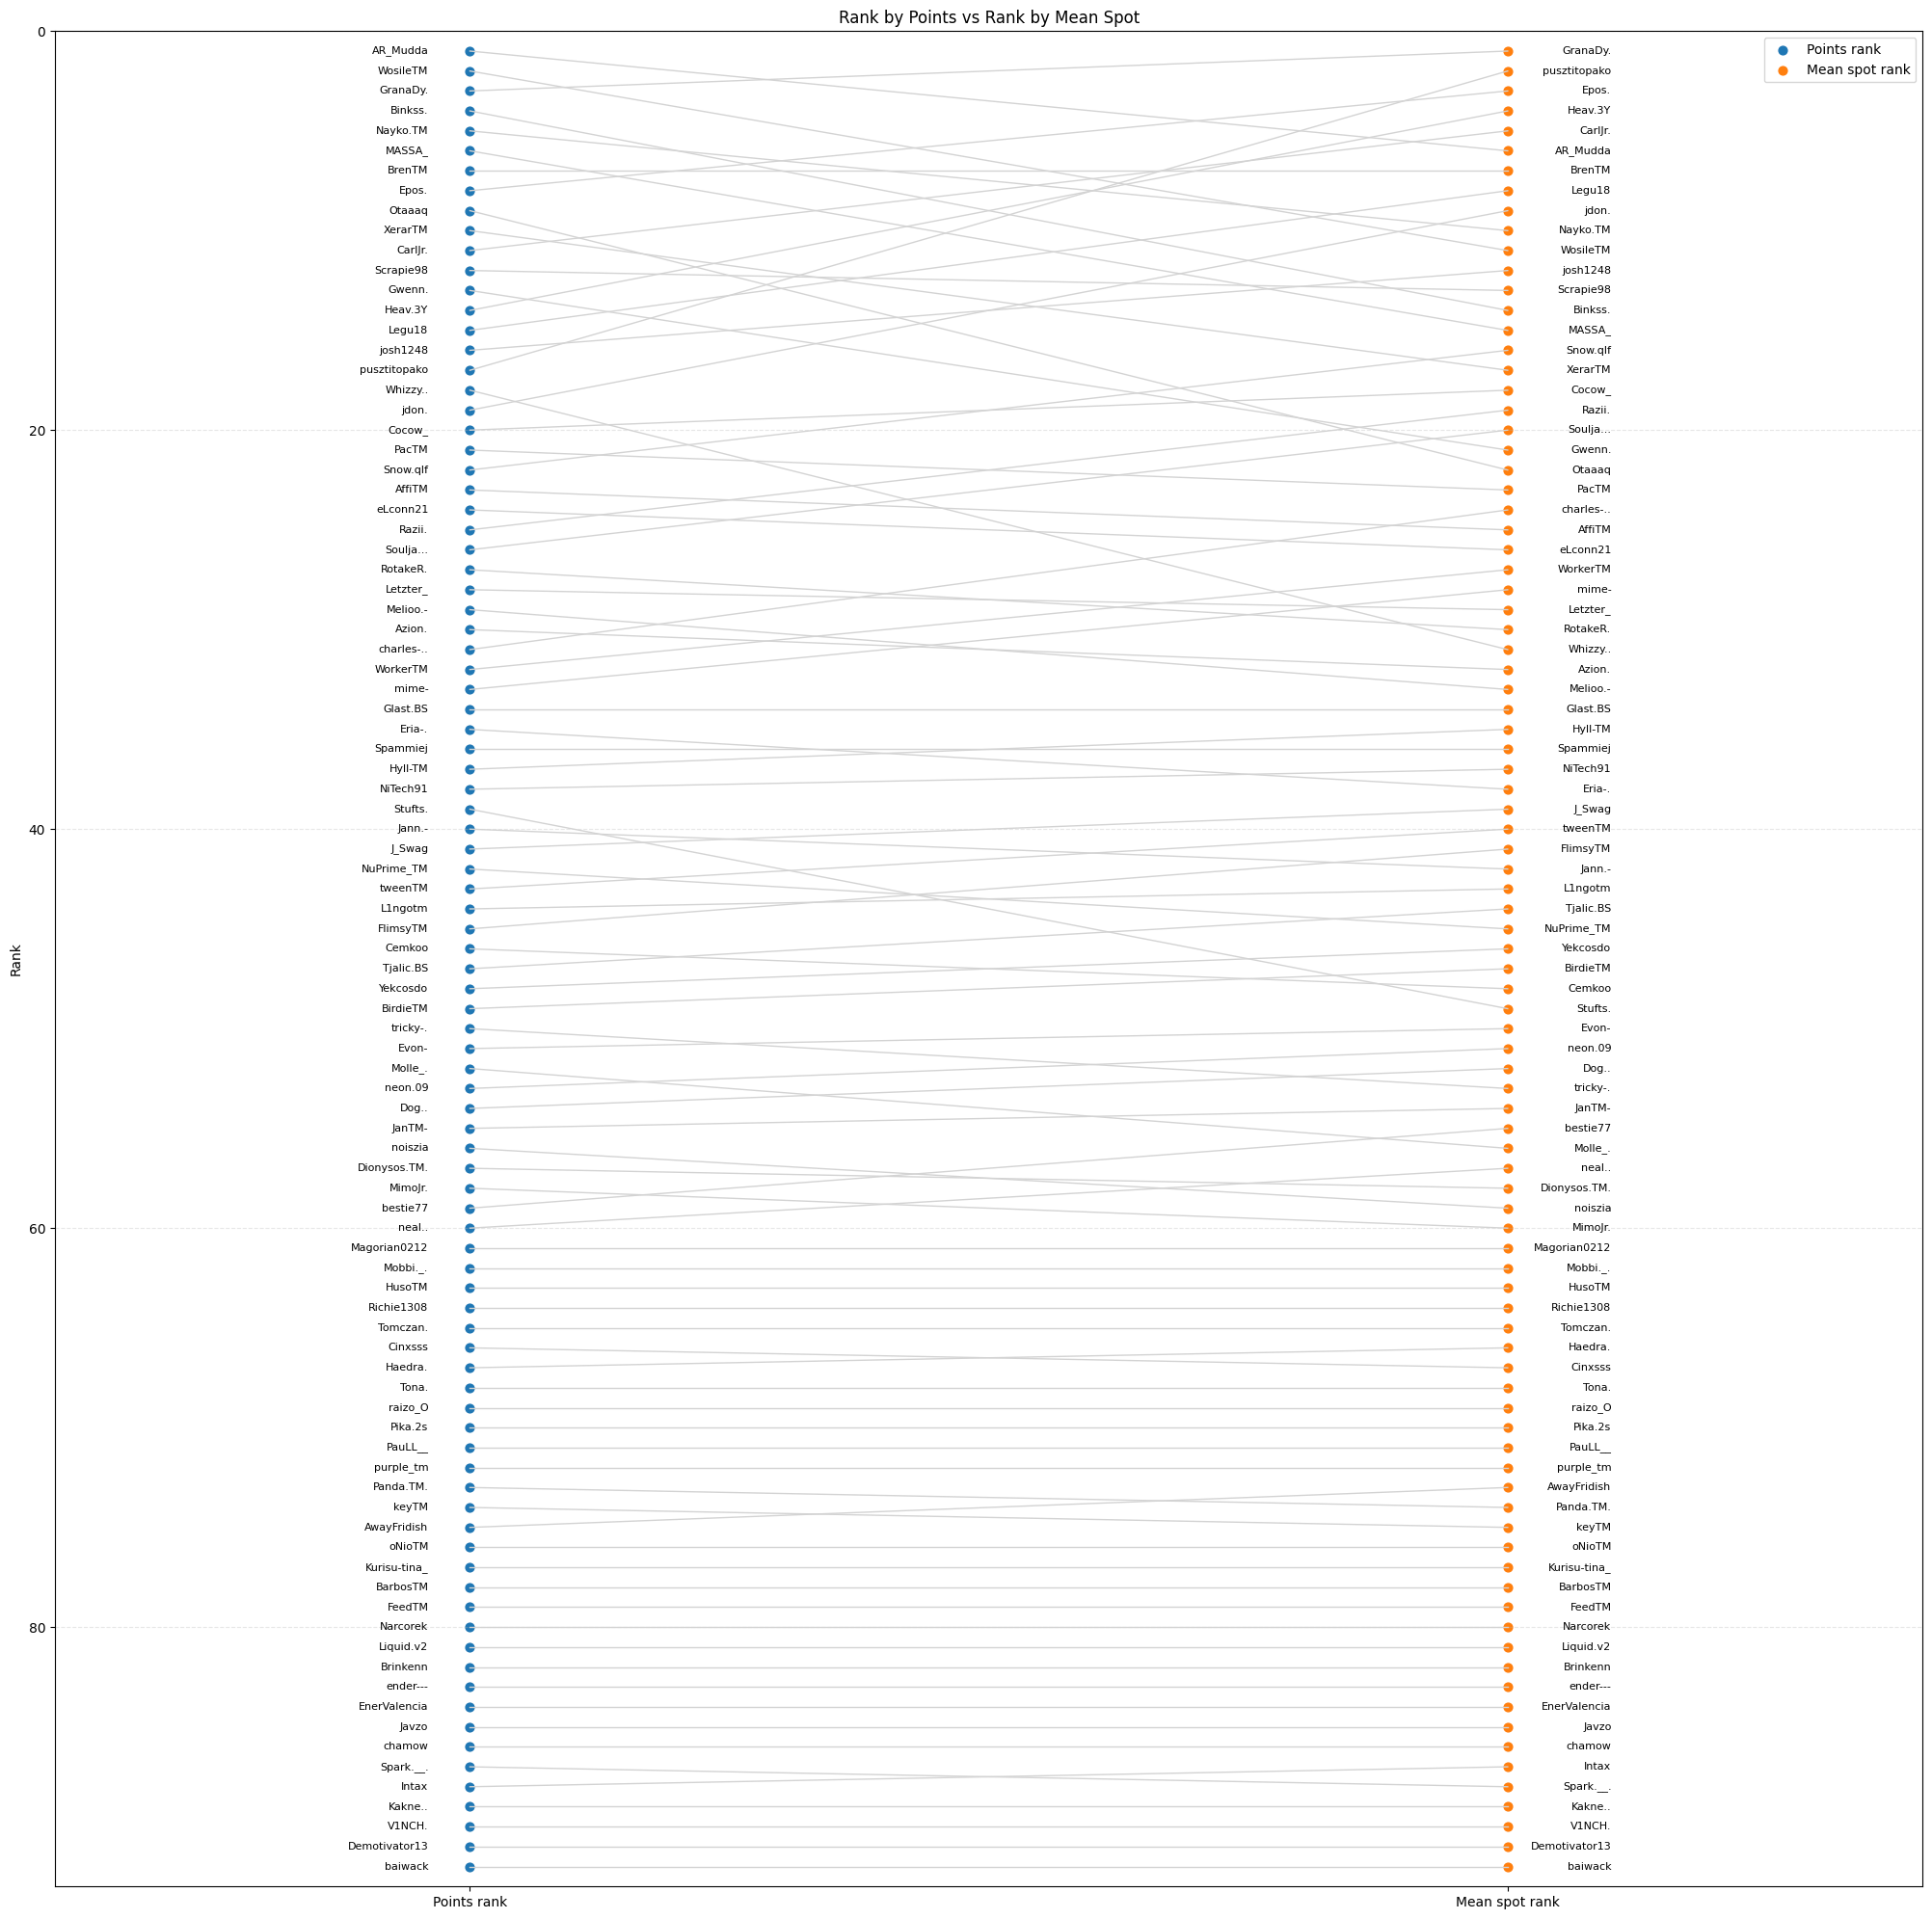

In [12]:
fig, ax = plt.subplots(figsize=(25,25))

toana = toana_roh.copy()

ax.scatter(
    [0 for _ in toana.rank_by_points],
    toana.rank_by_points,
    color="tab:blue",
    s=40,
    label="Points rank"
)

ax.scatter(
    [0.05 for _ in toana.rank_by_mean_spot],
    toana.rank_by_mean_spot,
    color="tab:orange",
    s=40,
    label="Mean spot rank"
)

for idx in toana.index:
    ax.plot(
        [0, 0.05],
        [toana.rank_by_points[idx], toana.rank_by_mean_spot[idx]],
        color="lightgray",
        linewidth=1
    )

ax.legend()

ax.set_xticks([0, 0.05])
ax.set_xticklabels(["Points rank", "Mean spot rank"])
ax.set_ylabel("Rank")
ax.set_title("Rank by Points vs Rank by Mean Spot")


ax.set_xlim(-0.02, 0.07)   # a bit of padding left/right
ax.grid(axis="y", linestyle="--", alpha=0.3)

for idx in toana.index:
    label = toana.player[idx]
    ax.text(0 - 0.002, toana.rank_by_points[idx],
            label,
            ha="right", va="center", fontsize=8)
    
    ax.text(0.05+0.005, toana.rank_by_mean_spot[idx],
            label,
            ha="right", va="center", fontsize=8)
    
ax.set_ylim(0,93)
ax.invert_yaxis()